In [1]:
from process_impl import config

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def plot_evaluation_metrics(evals_path):
    print(evals_path)
    data = np.load(evals_path)
    
    if 'timesteps' not in data or 'results' not in data:
        raise ValueError("O arquivo .npz deve conter 'timesteps' e 'results' (como salvo pelo EvalCallback)")

    timesteps = data['timesteps']
    results = data['results']  # shape: (n_evals, n_eval_episodes)

    # Média e desvio-padrão das recompensas
    mean_rewards = results.mean(axis=1)
    std_rewards = results.std(axis=1)

    # Encontrar índice onde o best model foi salvo
    best_idx = np.argmax(mean_rewards)
    best_mean_reward = mean_rewards[best_idx]
    best_timestep = timesteps[best_idx]
    best_std = std_rewards[best_idx]

    # Gráfico 1 – Curva de convergência com destaque no melhor modelo
    plt.figure(figsize=(8, 4))
    plt.plot(timesteps, mean_rewards, '.-', label='Mean Reward')
    plt.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.3, label='±1 std')
    plt.scatter([best_timestep], [best_mean_reward], color='red', zorder=5, label='Best Model')
    plt.annotate(
        f'Mean: {best_mean_reward:.2f}\nStd: {best_std:.2f}',
        xy=(best_timestep, best_mean_reward),
        xytext=(best_timestep, best_mean_reward + 0.05),
        textcoords='data',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='white'),
        arrowprops=dict(arrowstyle='->', color='red')
    )
    plt.xlabel("Timesteps")
    plt.ylabel("Mean Reward")
    plt.title("Convergência do Treinamento (Recompensa Média por Avaliação)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Gráfico 2 – Histograma da MELHOR avaliação
    plt.figure(figsize=(6, 4))
    plt.hist(results[best_idx], bins=10, alpha=0.7, color='orange')
    plt.title(f"Distribuição das Recompensas na Melhor Avaliação (t={best_timestep})")
    plt.xlabel("Reward")
    plt.ylabel("Frequência")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Gráfico 3 – Boxplot com destaque na melhor avaliação
    plt.figure(figsize=(10, 4))
    plt.boxplot(results.T, positions=timesteps, widths=timesteps[1] - timesteps[0])
    plt.axvline(x=best_timestep, color='red', linestyle='--', label='Best Model')
    plt.title("Boxplot das Recompensas por Avaliação")
    plt.xlabel("Timesteps")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

   
    # Supondo que você já tenha essas variáveis definidas:
    # timesteps: vetor 1D com os steps (ex: np.arange(len(mean_rewards)))
    # mean_rewards: vetor 1D com as médias
    # std_rewards: vetor 1D com os desvios padrão
    
    # Área sombreada do desvio padrão
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=np.concatenate([timesteps, timesteps[::-1]])*3,
        y=np.concatenate([mean_rewards + std_rewards, (mean_rewards - std_rewards)[::-1]]),
        fill='toself',
        fillcolor='lightgray',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=True,
        name='Reward Standard Deviation in Evaluation Simulations'
    ))
    
    # Linha da média
    fig.add_trace(go.Scatter(
        x=timesteps*3,
        y=mean_rewards,
        mode='lines',
        name='Mean Reward in Evaluation Simulations',
        line=dict(color='black', width=5)
    ))
        
    fig.update_layout(
        xaxis=dict(
            title=dict(
                text='Total learning steps',
                font=dict(size=20)
            ),
            tickfont=dict(size=16)
        ),
        yaxis=dict(
            title=dict(
                text='Sum of Rewards',
                font=dict(size=20)
            ),
            tickfont=dict(size=16)
        ),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.65,
            xanchor="center",
            x=0.5,
            font=dict(size=16)
        ),
        height=400,
        width=800
    )

    
    # Mostrar o gráfico
    fig.show()
    # Salvar como PNG com alta resolução
    fig.write_image("conv.png", format="png", width=800, height=400, scale=6, engine="kaleido")


In [3]:
cd = "C:\\Users\\Douglas\\Desktop\\codigos_mestrado9_aws_ph_forcle\\src\\models_\\best_model_ferm_224_reward_params_3.02_3.24_30.83_-0.64_9.12_-0.75_0.12_2.06__1_"



Running evaluation for variable: h1
h3 7 0.0 12.0 0.16666666666666674 0.16666666666666674
h4 7 0.0 12.0 0.16666666666666674 0.16666666666666674
k1 3 1.0 5.0 0.0 0.0
k2 3 1.0 5.0 0.0 0.0
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 9.574654341726394, 'h4': 11.633606188700469, 'k1': 0.0, 'k2': 0.0, 'h1': 0.42568473684165853, 'h2': -0.37505626347780485} {'h1': 7.0, 'h2': 7.0}
---intl reset [ 0.42568475 -0.37505627  9.574655   11.633606    0.          0.        ]
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 9.574654341726394, 'h4': 11.633606188700469, 'k1': 0.0, 'k2': 0.0, 'h1': 0.42568473684165853, 'h2': -0.37505626347780485}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.594305257805698, 'h4': 0.9379928262629991, 'k1': -1.5, 'k2': -1.5, 'h1': 0.4432435728271671, 'h2': -0.3473608054794092}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.576091319175273, 'h4': 0.9179060514799582, 'k1': -2.25, 'k2': -2.25, 'h1': 0.42719826143697426, 'h2': -0.3581359543767909}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'

C:\Users\Douglas\Desktop\codigos_mestrado9_aws_ph_forcle\processes\four_tanks\process_impl.py:23: RuntimeWarning: invalid value encountered in sqrt
  dh2_dt = -a2/A2 * np.sqrt(2 * g * h2) + gamma2 * k2/A2 * q2


  → Changing h1 to 8.5
  → Changing h1 to 10.0
{'h3': [0.594305257805698, 0.576091319175273, 0.5508028181930582, 0.5229686492374588, 0.49469891313699854, 0.4669698260222248, 0.44022837285298366, 0.4146757431181236, 0.39039960472276913, 0.3674355188376406, 0.3457952838702314, 0.32547991803846466, 0.30648553834061554, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.2888059603297035, 0.

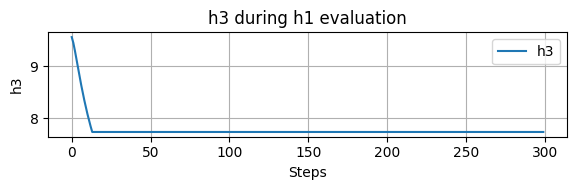

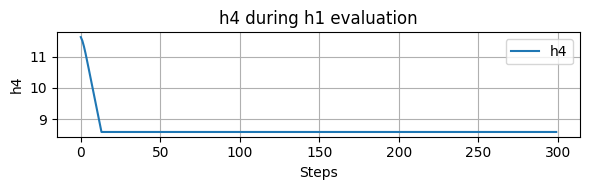

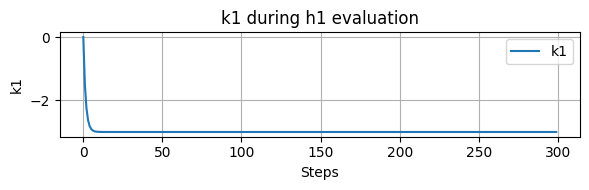

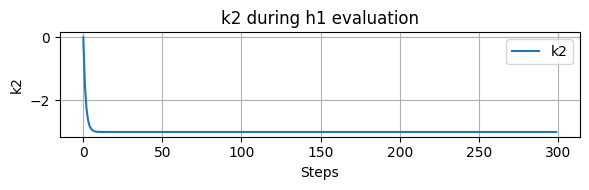

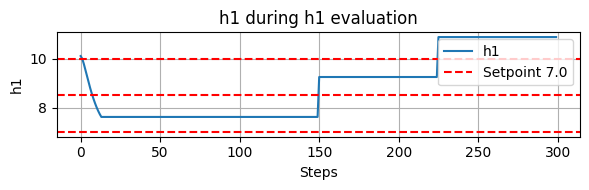

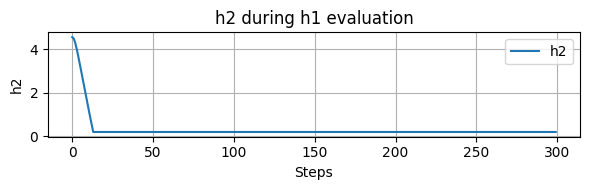

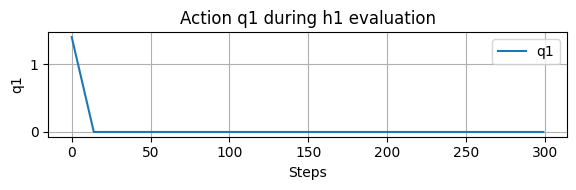

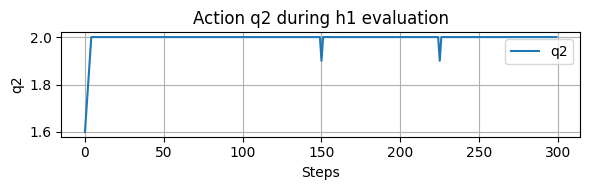

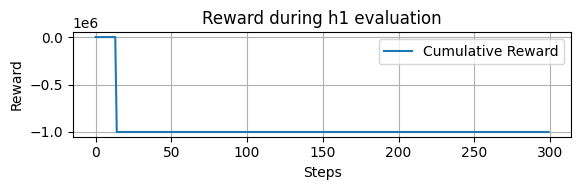


Running evaluation for variable: h2
h3 7 0.0 12.0 0.16666666666666674 0.16666666666666674
h4 7 0.0 12.0 0.16666666666666674 0.16666666666666674
k1 3 1.0 5.0 0.0 0.0
k2 3 1.0 5.0 0.0 0.0
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 11.24915522071446, 'h4': 11.971205057668051, 'k1': 0.0, 'k2': 0.0, 'h1': -0.12398893210461692, 'h2': -0.33875145367294035} {'h1': 7.0, 'h2': 7.0}
---intl reset [-0.12398893 -0.33875147 11.249155   11.971205    0.          0.        ]
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 11.24915522071446, 'h4': 11.971205057668051, 'k1': 0.0, 'k2': 0.0, 'h1': -0.12398893210461692, 'h2': -0.33875145367294035}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.8742524624796, 'h4': 0.9932945548851535, 'k1': -1.5, 'k2': -1.5, 'h1': -0.09821639770731139, 'h2': -0.31270327998876446}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.8544996428601042, 'h4': 0.972922460953626, 'k1': -2.25, 'k2': -2.25, 'h1': -0.11089022012706551, 'h2': -0.3237620034907501}
['h1', 'h2', 'h3', 'h4', 'k1', 

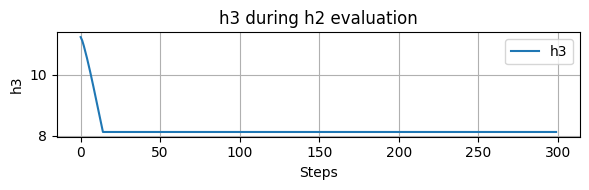

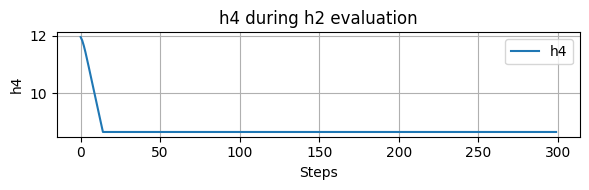

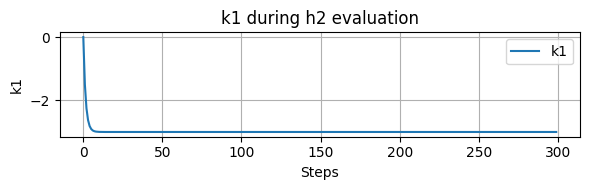

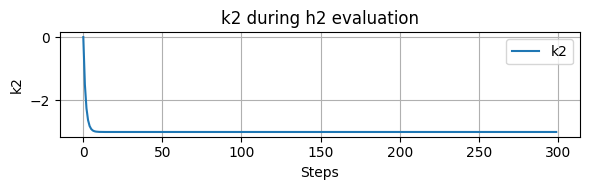

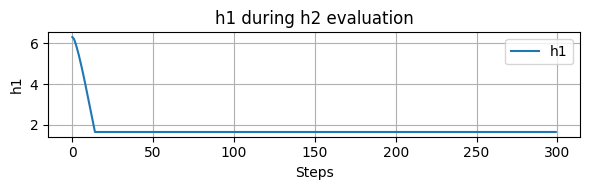

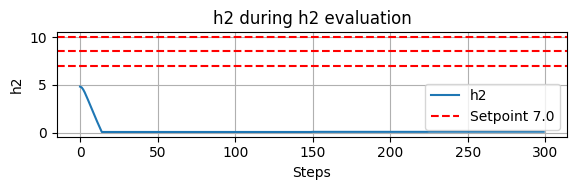

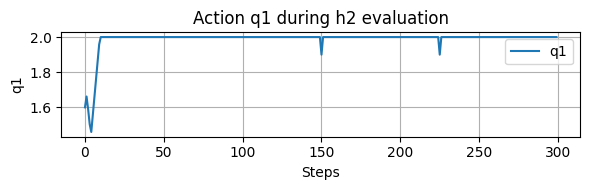

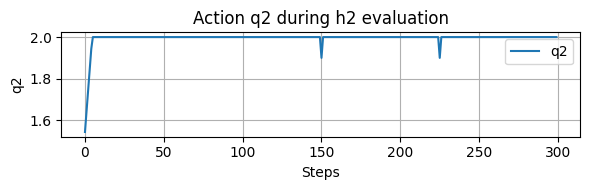

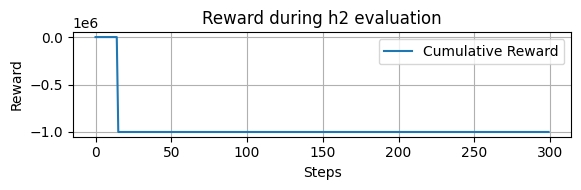


Running evaluation for variable: h3
h3 7 0.0 12.0 0.16666666666666674 0.16666666666666674
h4 7 0.0 12.0 0.16666666666666674 0.16666666666666674
k1 3 1.0 5.0 0.0 0.0
k2 3 1.0 5.0 0.0 0.0
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 8.79234276553845, 'h4': 10.903312301316394, 'k1': 0.0, 'k2': 0.0, 'h1': 0.07547358652092706, 'h2': 0.06173367431392962} {'h1': 7.0, 'h2': 7.0}
---intl reset [ 0.07547358  0.06173367  8.792343   10.903313    0.          0.        ]
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 8.79234276553845, 'h4': 10.903312301316394, 'k1': 0.0, 'k2': 0.0, 'h1': 0.07547358652092706, 'h2': 0.06173367431392962}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.4646805171585626, 'h4': 0.8145407957870185, 'k1': -1.5, 'k2': -1.5, 'h1': 0.09512090813880114, 'h2': 0.08150167954495902}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.4472248864323658, 'h4': 0.7951060149830942, 'k1': -2.25, 'k2': -2.25, 'h1': 0.08114983727874825, 'h2': 0.06761803426841695}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2']

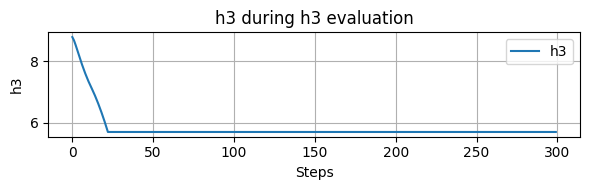

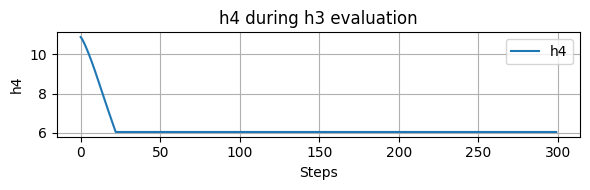

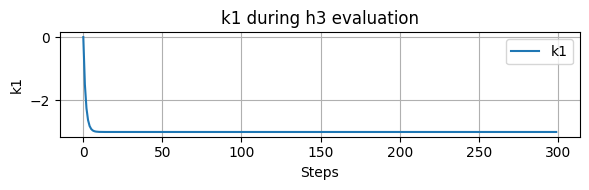

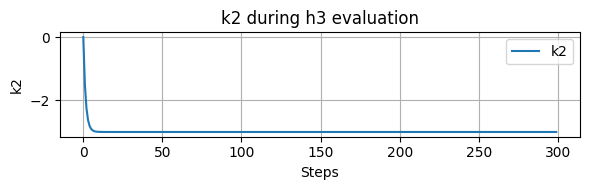

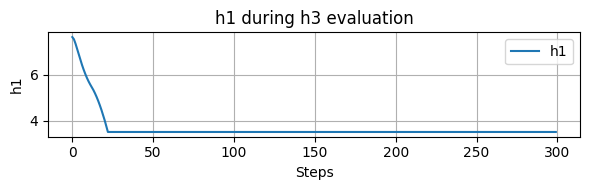

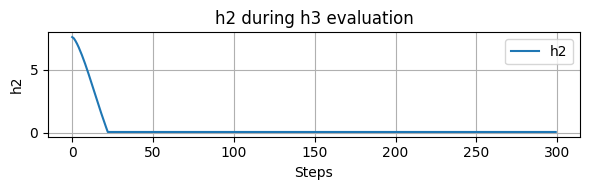

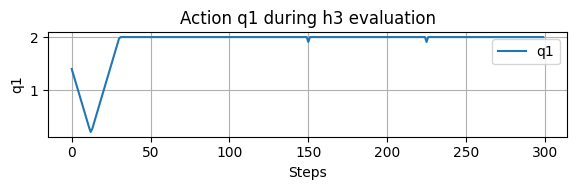

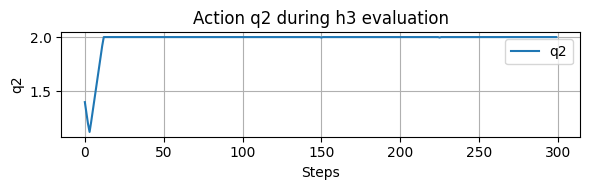

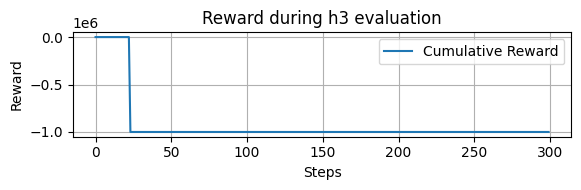


Running evaluation for variable: h4
h3 7 0.0 12.0 0.16666666666666674 0.16666666666666674
h4 7 0.0 12.0 0.16666666666666674 0.16666666666666674
k1 3 1.0 5.0 0.0 0.0
k2 3 1.0 5.0 0.0 0.0
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 10.31901837501928, 'h4': 11.196683516694502, 'k1': 0.0, 'k2': 0.0, 'h1': 0.4028547284439985, 'h2': 0.18177643357885231} {'h1': 7.0, 'h2': 7.0}
---intl reset [ 0.40285474  0.18177643 10.319018   11.196684    0.          0.        ]
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 10.31901837501928, 'h4': 11.196683516694502, 'k1': 0.0, 'k2': 0.0, 'h1': 0.4028547284439985, 'h2': 0.18177643357885231}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.7176706236606758, 'h4': 0.8631596598451479, 'k1': -1.5, 'k2': -1.5, 'h1': 0.42054136641005657, 'h2': 0.20075817910587057}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.698763141232388, 'h4': 0.843465535770014, 'k1': -2.25, 'k2': -2.25, 'h1': 0.4046231056285421, 'h2': 0.18612666856576987}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'

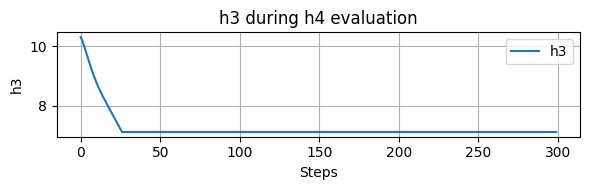

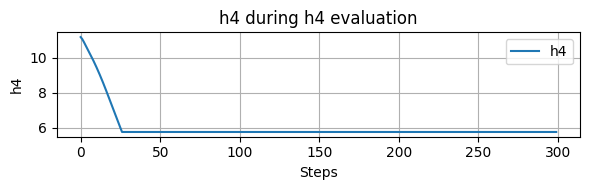

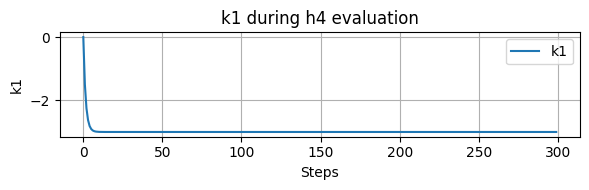

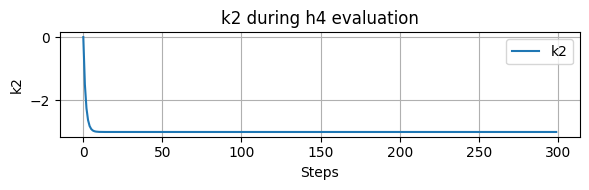

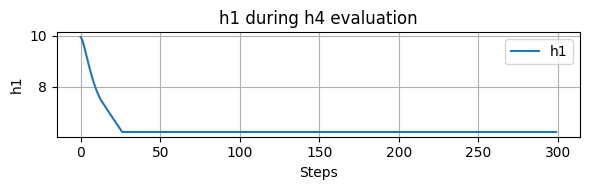

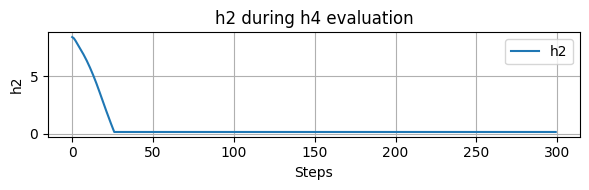

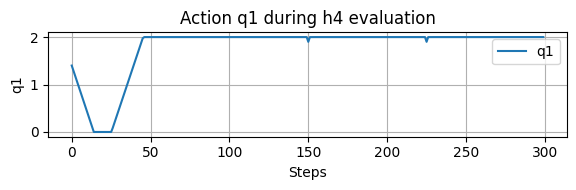

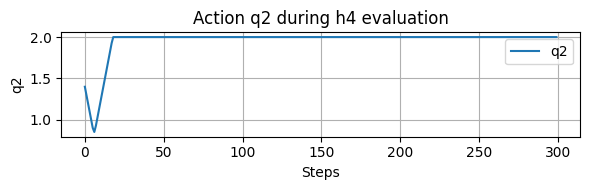

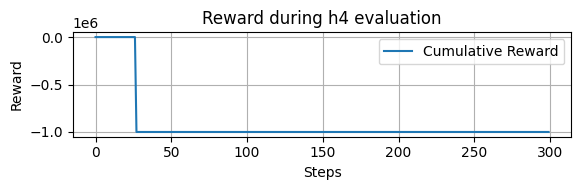


Running evaluation for variable: k1
h3 7 0.0 12.0 0.16666666666666674 0.16666666666666674
h4 7 0.0 12.0 0.16666666666666674 0.16666666666666674
k1 3 1.0 5.0 0.0 0.0
k2 3 1.0 5.0 0.0 0.0
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 9.512668369762192, 'h4': 7.761978621967309, 'k1': 0.0, 'k2': 0.0, 'h1': -0.10990787249928613, 'h2': 0.22805359584521168} {'h1': 7.0, 'h2': 7.0}
---intl reset [-0.10990787  0.2280536   9.512669    7.7619786   0.          0.        ]
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 9.512668369762192, 'h4': 7.761978621967309, 'k1': 0.0, 'k2': 0.0, 'h1': -0.10990787249928613, 'h2': 0.22805359584521168}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.5856419806888946, 'h4': 0.2940078938171127, 'k1': -1.5, 'k2': -1.5, 'h1': -0.08580259450596928, 'h2': 0.24675494690169542}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.5674777380680662, 'h4': 0.2776039088850193, 'k1': -2.25, 'k2': -2.25, 'h1': -0.09856365924702037, 'h2': 0.23184497852378283}
['h1', 'h2', 'h3', 'h4', 'k1', '

C:\Users\Douglas\Desktop\codigos_mestrado9_aws_ph_forcle\processes\four_tanks\process_impl.py:22: RuntimeWarning: invalid value encountered in sqrt
  dh1_dt = -a1/A1 * np.sqrt(2 * g * h1) + gamma1 * k1/A1 * q1


  → Changing k1 to 2
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': -0.1163118045938134, 'h4': -0.33444025994466586, 'k1': -2.9999996423721313, 'k2': -2.9999996423721313, 'h1': -0.980752159168261, 'h2': -0.6440105895910873}
  → Changing k1 to 4
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': -0.11392021427611454, 'h4': -0.37008261596502234, 'k1': -2.9999998211860657, 'k2': -2.9999998211860657, 'h1': -0.9512057426877811, 'h2': -0.699680014485969}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': -0.09560801084176529, 'h4': -0.4054015687007385, 'k1': -2.999999910593033, 'k2': -2.999999910593033, 'h1': -0.8909477994402021, 'h2': -0.7546719969769666}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': -0.13322135898205623, 'h4': -0.4403907089410919, 'k1': -2.9999999552965164, 'k2': -2.9999999552965164, 'h1': -0.9427911152981565, 'h2': -0.8089233593291874}
{'h3': [0.5856419806888946, 0.5674777380680662, 0.5414266824569538, 0.5124272052031971, 0.48278876513629676, 0.45354078791573316, 0.4250550547197962, 0.39719

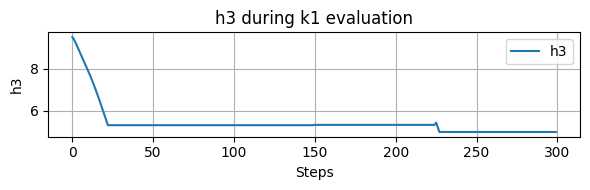

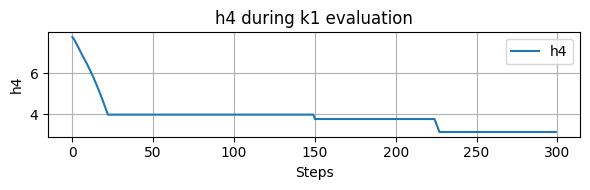

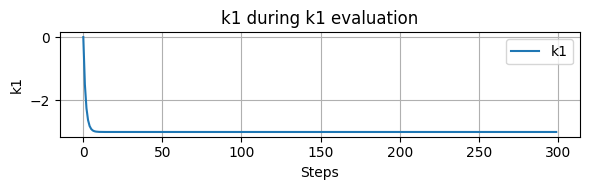

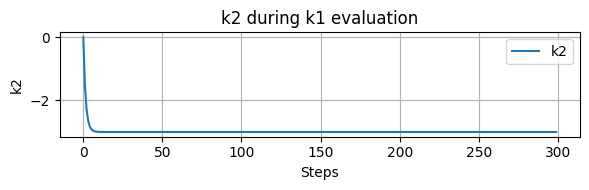

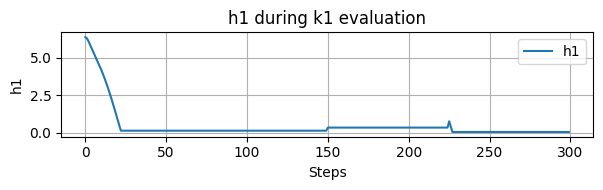

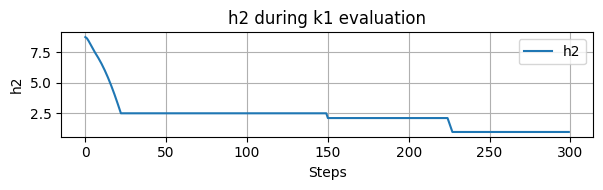

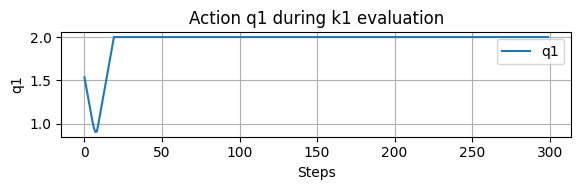

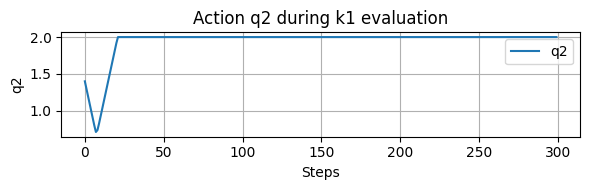

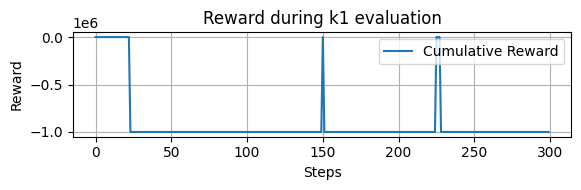


Running evaluation for variable: k2
h3 7 0.0 12.0 0.16666666666666674 0.16666666666666674
h4 7 0.0 12.0 0.16666666666666674 0.16666666666666674
k1 3 1.0 5.0 0.0 0.0
k2 3 1.0 5.0 0.0 0.0
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 7.594698703312383, 'h4': 10.354961372491523, 'k1': 0.0, 'k2': 0.0, 'h1': 0.3938695731748254, 'h2': 0.3643628340502778} {'h1': 7.0, 'h2': 7.0}
---intl reset [ 0.39386958  0.36436284  7.594699   10.354961    0.          0.        ]
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 7.594698703312383, 'h4': 10.354961372491523, 'k1': 0.0, 'k2': 0.0, 'h1': 0.3938695731748254, 'h2': 0.3643628340502778}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.26630559221670946, 'h4': 0.7236281913315576, 'k1': -1.5, 'k2': -1.5, 'h1': 0.41160679145208556, 'h2': 0.3822672984607818}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0.2500787097074, 'h4': 0.7046878572810604, 'k1': -2.25, 'k2': -2.25, 'h1': 0.39573881028322644, 'h2': 0.3665655554228}
['h1', 'h2', 'h3', 'h4', 'k1', 'k2'] {'h3': 0

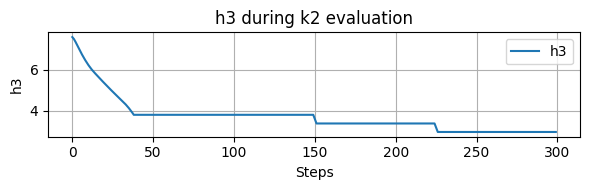

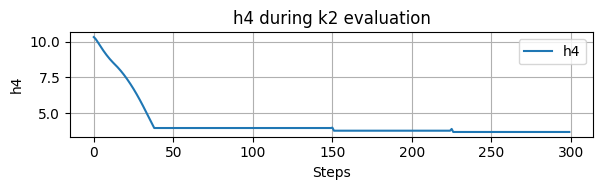

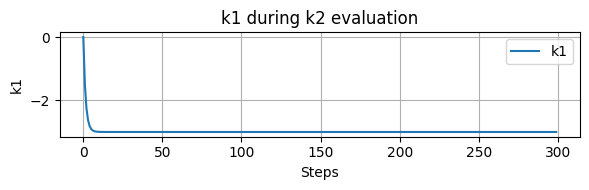

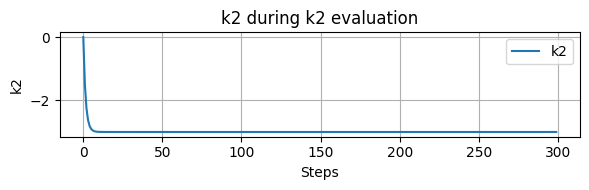

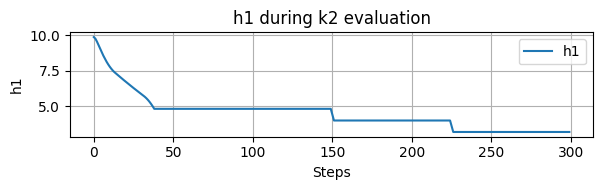

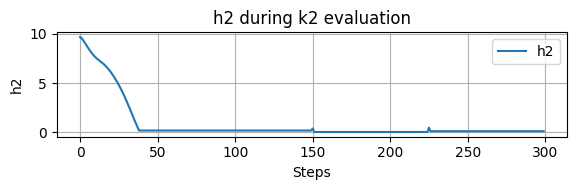

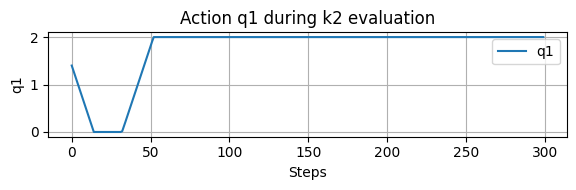

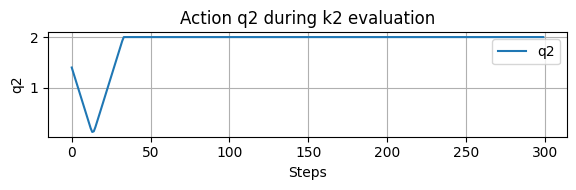

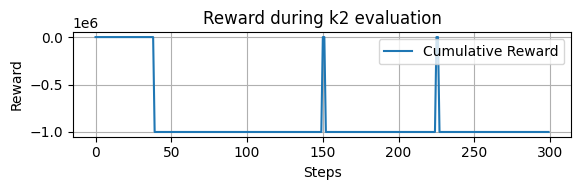

In [4]:
import sys
import os

# Caminho relativo a partir do notebook
sys.path.append(os.path.abspath(os.path.join("..", "..", "src")))

from eval_env_runner import EvaluationEnvRunner
cd = cd[:-2]+"1_"


runner = EvaluationEnvRunner(config, model_dir=cd)
runner.run_evaluations()


In [5]:
a=[1,2,3,2,1,2,23]

In [6]:
l = len(a)
a[int(l/3):] = [10]*int(l/2)

In [7]:
a

[1, 2, 10, 10, 10]

In [8]:
sum([i['IAE_total'] for i in lista_dict])

NameError: name 'lista_dict' is not defined

In [ ]:
[i['IAE_total'] for i in lista_dict]